# 핵심 키워드 추출 & 문서 요약

**과제 내용**

**[핵심 키워드 추출]**

1. **TextRank 구현** — 뉴스기사 하나를 전처리하고 TextRank 알고리즘을 구현해 핵심 키워드 추출
   - TextRank의 기본 원리를 PageRank와의 유사점·차이점을 기반으로 설명
2. **시각화** — 중요도 상위 10개 키워드를 적절한 그래프로 시각화
   - 어떤 그래프를 왜 사용했는가

**[문서 요약]**  

3. **Luhn Summarizer 구현** — 전처리한 기사를 Luhn 방식으로 요약
   - 중요 키워드를 선택하는 `a`, `b` 값을 바꿔가며 결과 확인
4. **TextRank 요약 구현** — 같은 데이터로 TextRank 요약 수행
   - TextRank를 문서 요약에 적용할 때의 장점을 **두 가지 관점**에서 설명
     1. 영어 뉴스를 수집해 동일하게 수행 → **언어 독립성**
     2. 비슷한 뉴스 10개를 합쳐서 수행 (100개·1000개는?) → **확장성**

---

**분석 대상 데이터**

| 구분 | 내용 |
|---|---|
| 한국어 기사 1건 | 지디넷코리아 「구글 "대만과 어깨 나란히"…AI 인프라 협력」 |
| 영어 기사 1건 | TechCrunch 「Nvidia confirms it will buy Hugging Face for $12.9 billion」 |
| 비슷한 기사 10건 | 지디넷코리아 메모리·반도체·디스플레이 기사 10건 |

---
## 0. 환경 설정

In [1]:
%pip install -q konlpy networkx scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx

warnings.filterwarnings("ignore")

### 0.1 데이터

In [3]:
KO_DOC_META = {
    "title": '구글 "대만과 어깨 나란히"…AI 인프라 협력, 발주에서 공동설계로',
    "press": "지디넷코리아",
    "url": "https://zdnet.co.kr/view/?no=20260905223908",
}

KO_DOC = """구글이 대만 공급망과의 관계를 단순 발주와 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다. 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고"라는 한 마디로 요약했다. 6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다. 그는 구글 텐서처리장치(TPU)와 AI 하드웨어 전략의 핵심 설계자로 꼽히는 인물이다. 15년간 구글 AI 인프라 개발에 참여하고 이를 주도해 왔으며, 지난해 말 CTO로 승진해 순다르 피차이 구글 최고경영자(CEO)에게 직접 보고한다. 이번 방문은 알파벳의 미디어텍 지분 투자와 맞물리며 시장의 주목을 받았다. 업계에서는 그가 행사 전 대만 공급망을 비공개로 방문해 TPU 서버 물량을 논의한 것으로 본다. 다만 바흐다트 CTO는 구체적인 수주나 협력 내용에 대해서는 공개하지 않았다. 미디어텍은 최근 39억달러 규모의 해외 전환사채를 발행했다. 이 가운데 엔비디아가 35억달러를 인수했고, 알파벳은 남은 물량 인수에 참여했다. 정확한 투자 금액은 공개되지 않았다. 바흐다트 CTO가 인터뷰에서 거듭 강조한 것은 협력 방식 자체가 근본적으로 달라졌다는 점이다. 바흐다트 CTO는 "이건 이미 구매와 파트너의 문제가 아니다"라며 구글과 대만 업체들이 이미 깊은 수준의 공동 설계 단계에 들어섰고, 이런 협력이 매달 매 분기 매년 가속되고 있다고 설명했다. 이어 "대만 파트너와 깊이 있는 공동 설계를 하지 않았다면 오늘날과 같은 인프라와 컴퓨팅 플랫폼을 만들어내는 것은 불가능했을 것"이라고 말했다. 그는 구글이 현재 여러 대만 협력사와 차세대 제품을 두고 논의를 진행 중이며, 협력 범위가 랙 레벨의 엔드투엔드 아키텍처 설계로까지 확장됐다고 전했다. 양산 설계와 신뢰성 향상 방식 등 대만 공급망의 엔지니어링 실행력이 인상적이었다는 평가도 내놨다. 구글 대만 팀은 구글 AI 하드웨어 개발의 중요한 역할을 맡고 있다. 바흐다트 CTO는 구글의 설계와 제조 작업 상당수가 대만에서 이뤄지며, TSMC 생산라인에서 칩이 나오면 대만 팀이 가장 먼저 테스트를 수행하는 경우가 많다고 설명했다. 24시간 가까이 구글과 협력사가 어깨를 맞대고 칩의 정상 작동 여부를 확인한 뒤 최대한 빨리 소프트웨어 개발팀에 넘긴다는 것이다. 대만은 구글이 미국 외 지역에 둔 최대 하드웨어 연구개발 거점이다. 바흐다트 CTO는 "타이베이 스린 AI 인프라 연구개발 센터의 사무 공간을 60% 확대하고 있으며, 팀 규모도 계속 커질 것"이라고 말했다. 구글은 올해 4월 '클라우드 넥스트' 행사에서 8세대 TPU를 처음으로 두 개의 독립된 칩으로 나눴다. 대규모 학습에 특화된 TPU 8t와 고동시성 추론을 겨냥한 TPU 8i다. 학습용과 추론용 칩의 분가가 맞춤형 칩의 세분화를 예고하는 것이냐는 질문에 그는 이런 흐름이 "어느 정도는 불가피하다"고 강조했다. 그러면서 "구글은 약 2년 전 이미 학습과 추론 두 워크로드의 수요 규모가 각각 전용 칩을 만들 만큼 커졌다고 판단해 분리를 결정했다"고 말했다. 바흐다트 CTO는 다음 전용칩 후보로는 중앙처리장치(CPU)를 지목했다. AI 에이전트가 동작할 때 대량의 데이터 이동과 작업 스케줄링이 필요해지면서 저지연 고빈도 통신 능력이 중요해지고 있다는 이유에서다. 칩 전용화와 함께 바흐다트 CTO가 제시한 다음 경쟁 축은 데이터 이동 최소화다. 바흐다트 CTO는 "연산은 싸다. 비싼 것은 데이터를 옮기는 일이다"라며 "데이터를 가능한 한 연산 유닛 가까이 두고 칩과 서버, 시스템 사이를 오가는 데이터 이동이 유발하는 전력 소모와 지연을 줄이는 것이 관건"이라고 역설했다. 구글이 최근 몇 년간 '풀스택 공동 설계'를 앞세운 배경도 여기에 있다. 칩과 랙, 데이터센터의 전력과 네트워크까지 아우르며 구글은 데이터센터를 서버를 담는 건물이 아니라 한 대의 거대한 컴퓨터로 본다. 바흐다트 CTO는 "우리는 데이터센터가 곧 컴퓨터라고 말한다"고 밝혔다."""

print(KO_DOC_META["title"])
print(f"{len(KO_DOC)}자")
print(KO_DOC[:150], "...")

구글 "대만과 어깨 나란히"…AI 인프라 협력, 발주에서 공동설계로
2041자
구글이 대만 공급망과의 관계를 단순 발주와 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다. 아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨를 나란히 하고"라는 한 마디로 요약했다 ...


In [4]:
EN_DOC_META = {
    "title": "Nvidia confirms it will buy Hugging Face for $12.9 billion",
    "press": "TechCrunch",
    "url": "https://techcrunch.com/2026/09/03/nvidia-confirms-it-will-buy-hugging-face-for-12-9-billion/",
}

EN_DOC = """After weeks of swirling rumors, Nvidia confirmed today that it has acquired Hugging Face for $12.93 billion. Hugging Face's platform hosts three million models, one million applications used by over 18 million developers, and half a million datasets. In a blog post, Nvidia's CEO Jensen Huang said that Hugging Face will continue to support open source and open-weight models and will work on expanding developer access. "Hugging Face will remain an open platform for the entire AI ecosystem. Developers will choose the models they want, the frameworks they want, the clouds and inference service providers they want and the computing platforms they want. Nvidia compute will not be required to build on or deploy through Hugging Face," said Huang. Huang touted Nvidia's contributions and said that the chip company has released more than 500 models and 250 open datasets on Hugging Face. He argued that the company builds open models to get developers across the world to use them. For a company like Nvidia, which is a dominant hardware platform for AI development and inference, an open ecosystem that it controls is beneficial as it can create a platform suited for its chips. Plus, Nvidia will be able to sell its unused capacity to enterprise customers packaged with Hugging Face's offering. Hugging Face was founded in 2016 and has raised over $395 million in funding to date. The company's last round was in 2023, when it raised $235 million led by Salesforce Ventures, with investments from Google, Amazon, IBM, and Nvidia. In a post on X, Hugging Face CEO Clem Delangue thanked the community for showing the company could be an alternative to closed-source APIs. "But for it to happen at a larger scale, it needs more compute, more support, more collaboration, and more visibility. That's why we went to talk to Jensen, who offered to do exactly that with us," said Delangue. Hugging Face has risen in prominence, with more models being released every day. Last year, the company rejected a $500 million deal from Nvidia. Last month, it was reported that Hugging Face is clocking $150 million in annualized revenue. In an interview in July, Delangue said that its growth rate is helping the platform to get close to profitability. Nvidia's Huang has been a strong proponent of open models. He wrote a letter, co-signed by several other organizations, to advocate for open-weight models to strengthen the position of the United States against rivals like China in the AI sector. The company is heavily investing in model development. Last month, it was reported that it struck a $6 billion deal with coding startup Poolside to develop open models. During its recent earnings call, the company said it has infused over $50 billion into AI frontier labs. Huang pitched open models while answering one of the analysts and said that almost all open models run on Nvidia hardware. He also signaled the importance of these models in cybersecurity. In July, Delangue said that Nvidia's open model helped Hugging Face defend against cyberattacks after proprietary models failed to protect the platform."""

print(EN_DOC_META["title"])
print(f"{len(EN_DOC)} chars")
print(EN_DOC[:150], "...")

Nvidia confirms it will buy Hugging Face for $12.9 billion
3103 chars
After weeks of swirling rumors, Nvidia confirmed today that it has acquired Hugging Face for $12.93 billion. Hugging Face's platform hosts three milli ...


In [5]:
SIMILAR_DOCS = [
{"id": "S01", "title": "삼성, '여권 타입' 갤Z폴드8 DDI 수급 비상...\"내년 개발물량도 활용\"",
 "url": "https://zdnet.co.kr/view/?no=20260828153538",
 "text": """삼성전자가 올해 처음 출시한 '여권 타입' 폴더블폰 갤럭시Z폴드8용 디스플레이 드라이버 IC(DDI) 수급에 비상이 걸렸다. Z폴드8 수요가 예상을 웃돌자 삼성전자가 부품 발주량을 늘리고 있지만, DDI를 위탁생산하는 대만 UMC의 해당 공정 생산능력이 한계치에 도달해 DDI 생산일정을 앞당기기 어려운 것으로 알려졌다. DDI가 여러 부품 중에서도 범용성이 특히 떨어져 병목이 되고 있다. 삼성전자는 올해 폴더블폰 신제품을 기존 모델인 북 타입 갤럭시Z폴드8울트라, 클램셸 타입 Z플립8, 그리고 여권 타입 Z폴드8까지 3종을 출시했다. 출시 전부터 관심이 집중된 Z폴드8 수요가 예상을 웃돌고 있다. 28일 업계에 따르면 삼성전자가 갤럭시Z폴드8 부품 발주량을 당초 예상치보다 늘리고 있지만, 여러 부품 중 DDI 수급이 특히 빡빡한 것으로 파악됐다. Z폴드8용 DDI는 삼성전자 시스템LSI사업부가 설계하고, 대만 반도체 위탁생산 업체 UMC가 22나노미터 공정에서 만든다. 한 업계 관계자는 UMC의 22나노 공정 생산능력이 현재 한계치에 도달했다며 삼성전자가 UMC에 갤럭시Z폴드8용 DDI에 대해 급행 서비스를 요청했지만 UMC에선 어렵다고 답했다고 밝혔다. UMC는 현재 22나노 공정에서 다른 반도체도 생산 중이다. UMC가 갤럭시Z폴드8용 DDI 생산속도를 앞당기려면 다른 제품 생산계획도 조정해야 하는데, 이것이 어려운 것으로 추정된다. 삼성전자 폴더블폰 3종의 DDI 사양이 서로 다른 것도 원인이다. LPDDR 같은 D램은 범용품인 데다 모델별 물량이 부족하면 다른 모델 물량을 우선 배정할 수 있지만, DDI는 맞춤형 제품이어서 당초 확보한 생산능력과 생산속도에 좌우될 수밖에 없다."""},
{"id": "S02", "title": "삼성전자, 기흥 신규 R&D팹 '파운드리' 활용 추진…엔비디아 수요 선제 대응",
 "url": "https://zdnet.co.kr/view/?no=20260814101300",
 "text": """삼성전자가 기흥에 구축 중인 차세대 반도체 연구개발 단지 용도를 변경할 예정이다. 현재 해당 라인은 파운드리 생산능력 확대에 활용하기로 가닥을 잡은 것으로 14일 파악됐다. 당초 D램 양산용 라인으로도 투자가 논의됐으나 최근 계획이 수정됐다. 이곳에서 주력으로 노리는 양산품은 차세대 고대역폭메모리(HBM)용 2나노미터 베이스 다이다. 엔비디아 등 핵심 고객 주도로 HBM 공급이 확대될 전망인 만큼, 관련 생산능력을 미리 확보하려는 전략으로 풀이된다. 반도체 업계에 따르면 삼성전자는 기흥에 구축 중인 NRD-K 2라인 용도를 기존 연구개발에서 파운드리 라인으로 활용하는 방안을 추진 중이다. NRD-K는 삼성전자가 미래 반도체 기술을 선점하기 위해 건설 중인 최첨단 복합 연구개발단지다. 오는 2030년까지 약 20조원을 투입해 총 3개 라인을 조성하기로 했다. 이 중 첫 번째 라인은 지난 2024년 말 준공됐다. 올해부터 NRD-K 2라인 조성을 준비하고 있다. 목표로 검토 중인 주력 양산품은 엔비디아에 공급하는 HBM용 2나노 베이스 다이로 알려졌다. 베이스 다이는 HBM에서 여러 개의 D램을 수직으로 적층한 코어 다이 아래에 위치해, HBM과 그래픽처리장치 등 시스템반도체 간 데이터 전송을 지원한다. HBM 성능을 좌우하는 요소 중 하나다. HBM은 글로벌 빅테크의 공격적인 인공지능 인프라 투자에 따라 수요가 지속 확대될 것으로 관측된다. 특히 삼성전자는 향후 상용화될 커스텀 HBM과 HBM5에 업계 최첨단 공정인 2나노 기술을 적용해 경쟁사보다 성능 우위를 확보할 계획이다."""},
{"id": "S03", "title": "SK하이닉스, 日키오시아 최대주주 등극",
 "url": "https://zdnet.co.kr/view/?no=20260811094913",
 "text": """SK하이닉스가 일본 최대 낸드 제조기업 키오시아 최대주주로 올라섰다. 10일 닛케이신문에 따르면 키오시아는 회사 최대주주가 기존 도시바에서 특수목적법인으로 변경됐다고 공시했다. 해당 특수목적법인은 SK하이닉스가 전환사채로 투자한 회사다. 도시바는 키오시아 지분을 15.10% 보유해 왔다. 그러나 지난달 15일부터 이달 3일까지 총 7차례에 걸친 매도를 통해 지분을 14.06%까지 줄였다. 이로 인해 키오시아 지분을 14.19% 보유한 특수목적법인이 회사 최대주주로 등극하게 됐다. 앞서 SK하이닉스는 지난 2018년 총 2개 특수목적법인을 통해 키오시아에 약 4조원을 투자한 바 있다. 이 중 베인캐피탈 등과 함께 출자한 법인은 지난 6월 베인캐피탈이 투자금을 회수하면서 지분이 전량 매각됐다. 반면 SK하이닉스는 약 1조 3000억원을 투자한 법인을 지속 보유해 왔다. 전환사채를 주식으로 전환하는 경우 SK하이닉스는 키오시아에 대한 의결권을 가진 주주가 될 수 있다."""},
{"id": "S04", "title": "삼성전자, 온양캠퍼스 HBM 신규팹 다음달 착공…6조원 규모",
 "url": "https://zdnet.co.kr/view/?no=20260819171714",
 "text": """삼성전자가 다음달 충청남도 온양캠퍼스 내 고대역폭메모리(HBM) 신규 공장 건립을 시작한다. 투자금액은 6조원이다. 충청남도는 삼성전자 아산 온양캠퍼스 반도체 제조공장 증설에 필요한 도시계획위원회 심의를 마쳤다고 19일 밝혔다. 도는 이날 도청 대회의실에서 2026년 제8회 도시계획위원회를 열고 아산시 배방읍 북수리 일원 삼성전자 온양캠퍼스 증설 안건을 심의하고 의결했다. 이번 증설 사업은 온양캠퍼스 내 38만 9825제곱미터 부지에 HBM 등 고성능 인공지능 반도체 생산 확대를 위한 새 공장을 세우는 프로젝트다. 충청남도는 관계기관 사전 협의와 행정 검토를 신속히 추진해 도시계획위원회 심의 일정을 당초 계획보다 1개월 이상 단축했다. 삼성전자는 다음 달 신규 공장 착공에 들어갈 예정이다. 완공 시점은 공개되지 않았다."""},
{"id": "S05", "title": "\"2028년까지 메모리 공급난\"…증권가, 삼성전자 '주가 재평가' 전망",
 "url": "https://zdnet.co.kr/view/?no=20260905121046",
 "text": """국내외 증권가가 강력한 메모리 수요와 제한적 공급을 근거로 국내 반도체 기업 주가가 저평가됐다는 분석을 잇달아 내놨다. 글로벌 빅테크 기업의 장기공급계약 체결 요구가 이어지며 공급난이 2028년까지 지속될 것으로 보이는 가운데, 실적 개선과 주주환원이 맞물려 주가 재평가가 이뤄질 것이란 진단이다. 5일 업계에 따르면 KB증권과 글로벌 투자은행 노무라 등은 메모리 반도체 시장의 구조적 공급 부족에 주목했다. 김동원 KB증권 리서치본부장은 미국에 이어 바이두, 알리바바 등 중국 하이퍼스케일러까지 5년 장기공급계약 요구가 급증하고 있다며 신규 생산라인 완공부터 양산까지 3년 이상 걸려 공급 부족은 최소 2028년까지 이어질 것이라고 예상했다. 노무라의 연구원 역시 고객사들이 물량 부족으로 완제품 감산까지 감수하며 불리한 계약 조건을 수용 중이라며 중국 업체들 증설에도 2028년까지 공급 증가 여지는 제한적이라고 진단했다. 노무라는 이러한 호황 국면에도 주요 메모리 업체 주가가 여전히 고점 대비 37% 낮은 수준이라고 평가했다. 연구원은 2027년 예상 주가수익비율이 평균 약 3배에 불과하다며 펀더멘털에 비해 주가가 심각하게 저평가돼 있다고 강조했다. 노무라는 삼성전자와 SK하이닉스에 매수 의견을 유지했다."""},
{"id": "S06", "title": "2분기 글로벌 낸드 매출 70% 급증…삼성·SK 점유율 절반 육박",
 "url": "https://zdnet.co.kr/view/?no=20260904150718",
 "text": """올해 2분기 글로벌 낸드플래시 시장 매출이 제품 가격 급등에 힘입어 전 분기 대비 70% 폭증했다. 삼성전자와 SK하이닉스는 합산 점유율 47%를 기록하며 글로벌 1위와 2위 자리를 굳건히 지켰다. 4일 시장조사업체 카운터포인트리서치에 따르면 올해 2분기 글로벌 낸드플래시 시장 매출은 직전 분기 대비 70% 큰 폭으로 증가했다. 같은 기간 낸드 평균 판매 가격이 55% 오른 점이 시장 규모 확대를 이끌었다. 지난 1분기에도 낸드 가격이 전 분기 대비 90% 치솟은 데 이어 2개 분기 연속 가파른 가격 반등세가 지속된 결과다. 제조사별 매출 점유율을 보면 삼성전자가 28%로 1위를 수성했다. 전 분기 대비 점유율은 1%포인트 소폭 낮아졌으나 선두 자리를 안정적으로 유지했다. SK하이닉스는 점유율 19%로 2위를 기록했다. 이로써 삼성전자와 SK하이닉스의 합산 점유율은 47%에 달해, 국내 반도체 양사가 전 세계 낸드플래시 매출의 절반 가까이를 차지하고 있는 것으로 집계됐다. 미국 마이크론은 고부가 고가 제품 중심의 믹스 개선에 집중하면서 점유율을 전 분기 13%에서 15%로 끌어올려 3위에 올라섰다."""},
{"id": "S07", "title": "삼성전자, 2분기 HBM 점유율 33%로 급등…SK하이닉스와 격차 축소",
 "url": "https://zdnet.co.kr/view/?no=20260903162217",
 "text": """삼성전자가 고대역폭메모리(HBM) 시장에서 업계 1위 SK하이닉스와 격차를 좁혔다. 올 2분기 양사 점유율 차이는 17%포인트로, 전년 동기 43%포인트, 전 분기 37%포인트 대비 크게 줄었다. 3일 시장조사업체 카운터포인트리서치에 따르면 올 2분기 전세계 HBM 시장 점유율은 SK하이닉스가 50%로 1위를 유지했다. 다만 점유율 수치는 지속 감소하고 있다. SK하이닉스의 올 2분기 점유율은 전 분기 대비 8%포인트, 전년 동기 대비 14%포인트 감소했다. 반면 삼성전자는 올 2분기 33% 점유율로 SK하이닉스와 격차를 17%포인트로 좁혔다. 전 분기 대비 12%포인트, 전년 동기 대비 18%포인트 개선했다. 카운터포인트리서치는 삼성전자가 HBM4 출하를 본격화하면서 점유율이 점차 늘어날 것이라고 내다봤다. HBM4는 올해 본격 상용화된 최신형 HBM이다. 엔비디아의 고성능 인공지능 가속기 베라 루빈 시리즈에 탑재된다."""},
{"id": "S08", "title": "中 낸드, 글로벌 1위 되기 어려운 이유",
 "url": "https://zdnet.co.kr/view/?no=20260902102355",
 "text": """글로벌 낸드 플래시 메모리 산업 지형도가 급변하고 있다. 선두업체를 추격하기 위해 해외 후발주자 기업들이 앞다퉈 공격적인 증설 계획을 꺼내들고 있다. 특히 중국 양쯔메모리테크놀로지스(YMTC)의 투자 속도가 매우 빠른 것으로 평가된다. 반면 시장점유율 1위인 삼성전자의 낸드 투자는 증설보다 세대 전환에 초점이 맞춰져 있어 총 생산능력이 오히려 감소하는 추세다. 때문에 삼성전자와 후발주자간 낸드 생산능력 격차가 2~3년 내 빠르게 좁혀질 것이라는 우려도 제기된다. 다만 기업 간 낸드 경쟁을 단순히 생산능력만으로 평가할 수는 없다는 게 업계 전문가들의 중론이다. 데이터를 저장하는 셀을 복수로 쌓는 낸드 특성 상, 동일한 양의 웨이퍼를 투입하더라도 적층 수에 따라 메모리 총량이 크게 달라지기 때문이다. 시장 측면에서의 한계도 존재한다. YMTC의 총 낸드 출하량은 삼성전자와 SK하이닉스를 위협하는 추세지만, 인공지능 데이터센터에 필요한 기업용 SSD 매출은 아직 5위권 밖에 머물러 있다. 중국 현지 외 글로벌 고객사 확보가 어렵다는 점도 문제다. 최근 업계 낸드의 최대 화두는 중국 YMTC의 공격적인 설비 투자다. YMTC는 중국 최대 낸드 제조업체로 우한시에 주요 생산거점을 두고 있다. 올해 말에는 신규 3공장의 가동을 앞두고 있다. 업계가 추산하는 YMTC의 생산능력은 웨이퍼 투입량 기준 월 16만장에서 17만장 수준이다. 우한 3공장이 본격 가동되는 내년에는 월 20만장을 넘어설 것으로 전망된다."""},
{"id": "S09", "title": "中 BOE, 아이폰 OLED 공급 비중 줄어…삼성·LGD 수혜 기대",
 "url": "https://zdnet.co.kr/view/?no=20260904112859",
 "text": """중국 BOE의 애플 아이폰향 OLED 사업이 예상보다 부진한 것으로 나타났다. 올 1분기 기준 BOE가 차지하는 공급 비중은 약 14% 수준으로 지속 감소하는 흐름을 보이고 있다. 반대로 삼성디스플레이와 LG디스플레이는 반사이익을 누릴 것으로 기대된다. 허무열 옴디아코리아 수석연구원은 4일 서울 양재 엘타워에서 열린 2026 옴디아 한국 디스플레이 컨퍼런스에서 스마트폰 OLED 시장 동향에 대해 이같이 밝혔다. 애플은 스마트폰용 OLED 시장의 핵심 고객사로, 주요 디스플레이 기업 3사인 삼성디스플레이와 LG디스플레이, BOE로부터 패널을 수급하고 있다. 전통적으로 삼성디스플레이가 가장 많은 물량을 공급해 왔다. 지난 2021년 공급망에 진입한 BOE는 꾸준히 비중 확대를 추진해 왔다. 그러나 아이폰 OLED 내 BOE의 공급 비중은 당초 예상보다 더디게 성장하고 있는 것으로 나타났다. 올 1분기 비중은 14%로 집계됐다. 삼성디스플레이는 59%, LG디스플레이는 27%다. 가장 큰 원인은 품질 문제다. 특히 OLED 중에서도 기술 장벽이 높은 저온다결정산화물 패널 구현에서 지속적인 불량이 발생한 것으로 알려졌다. 반대로 삼성디스플레이와 LG디스플레이는 올해 아이폰향 OLED 사업에서 견조한 실적을 기록할 것으로 관측된다."""},
{"id": "S10", "title": "\"애플, 메모리 여파로 맥북프로 전략 수정…LCD·OLED 병행 판매\"",
 "url": "https://zdnet.co.kr/view/?no=20260903115517",
 "text": """메모리 가격 상승이 애플 IT 제품 유기발광다이오드(OLED) 채용 전략에도 영향을 미칠 것이란 전망이 나왔다. 당초 애플은 일부 아이패드와 맥북 모델의 디스플레이를 액정표시장치에서 OLED로 전량 교체할 예정이었으나, LCD와 OLED 모델을 병행 판매하는 방안을 추진 중이란 내용이다. 애플 IT 제품 OLED 시장 확대 속도도 앞선 기대보다 늦어질 가능성이 커졌다. 박진한 옴디아 이사는 3일 서울 양재 엘타워에서 열린 2026 옴디아 한국 디스플레이 컨퍼런스에서 중소형 OLED 시장 전망에 대해 이같이 밝혔다. 애플은 현재 아이폰과 아이패드 프로에 OLED를 적용 중이다. 올해는 OLED 아이패드 미니와 OLED 맥북 프로를 출시할 예정이다. 향후 아이패드 에어 등에도 OLED를 채용할 계획이다. 박 이사는 올해 노트북 시장이 역성장하고 있고 애플도 제품 가격 인상으로 올해 하반기 판매량이 상당히 안 좋을 것이란 우려가 나온다고 밝혔다. 당초 애플은 맥북 프로 LCD 모델을 단종하고 맥북 프로를 전량 OLED로 바꿀 계획이었다. 그러나 최근 LCD 모델은 유지하고 하이엔드급 맥북 프로 OLED 모델을 추가해 병행 판매하는 방안을 고려 중이다. 박 이사는 애플의 병행 판매는 적어도 내년 말까지 유지될 것이라며 결과적으로 애플의 IT OLED 판매량이 당초 예상보다 크게 줄어들 수밖에 없는 상황이라고 말했다."""},
]

for d in SIMILAR_DOCS:
    print(f"{d['id']} {len(d['text']):>5}자  {d['title'][:40]}")

S01   843자  삼성, '여권 타입' 갤Z폴드8 DDI 수급 비상..."내년 개발물량도 
S02   781자  삼성전자, 기흥 신규 R&D팹 '파운드리' 활용 추진…엔비디아 수요 선제
S03   489자  SK하이닉스, 日키오시아 최대주주 등극
S04   407자  삼성전자, 온양캠퍼스 HBM 신규팹 다음달 착공…6조원 규모
S05   624자  "2028년까지 메모리 공급난"…증권가, 삼성전자 '주가 재평가' 전망
S06   566자  2분기 글로벌 낸드 매출 70% 급증…삼성·SK 점유율 절반 육박
S07   465자  삼성전자, 2분기 HBM 점유율 33%로 급등…SK하이닉스와 격차 축소
S08   736자  中 낸드, 글로벌 1위 되기 어려운 이유
S09   637자  中 BOE, 아이폰 OLED 공급 비중 줄어…삼성·LGD 수혜 기대
S10   686자  "애플, 메모리 여파로 맥북프로 전략 수정…LCD·OLED 병행 판매"


### 0.2 전처리

과제1·2에서 만든 파이프라인을 재사용한다.  
키워드 추출은 **명사(NNG/NNP)와 영문(SL)** 만 노드로 삼는다.  
TextRank 원 논문(Mihalcea & Tarau, 2004)도 명사·형용사만 그래프의 노드로 쓴다.

In [6]:
from konlpy.tag import Komoran

# 분석기가 쪼개는 고유명사를 사용자 사전으로 보완
USER_DIC = """\\
바흐다트\tNNP
순다르 피차이\tNNP
세미콘 타이완\tNNP
미디어텍\tNNP
텐서처리장치\tNNP
타이베이\tNNP
키오시아\tNNP
카운터포인트리서치\tNNP
삼성디스플레이\tNNP
LG디스플레이\tNNP
SK하이닉스\tNNP
삼성전자\tNNP
공급망\tNNG
데이터센터\tNNG
"""
with open("user_dic.txt", "w", encoding="utf-8") as f:
    f.write(USER_DIC)

komoran = Komoran(userdic="./user_dic.txt")
print(komoran.pos("SK하이닉스가 키오시아 최대주주로 올라섰다."))

[('SK하이닉스', 'NNP'), ('가', 'JKS'), ('키오시아', 'NNP'), ('최', 'NNP'), ('대주주', 'NNP'), ('로', 'JKB'), ('오르', 'VV'), ('아', 'EC'), ('서', 'VV'), ('었', 'EP'), ('다', 'EF'), ('.', 'SF')]


In [7]:
STOP_WORDS = set("""
것 등 수 때 중 점 내 외 위 뒤 앞 안 밖 곳 만큼 가지 대비 기준 경우 관련 통해 대해 위해
하다 되다 있다 없다 이다 아니다 같다 보다 두다 오다 가다 내다 지다 늘다 크다 많다 적다
위하다 대하다 통하다 따르다 이번 지난 최근 올해 내년 현재 향후 이후 이전 지난해 전년 동기 기간
우리 그것 이것 이런 그런 이어 다만 특히 또한 함께 가장 매우 이미 실제 대한 각각
기자 사진 제공 자료 출처 보도 외신 업계 회사 소개 공개 발표 진행 확대 강화 말
""".split())
KEEP_ONE_CHAR = {"칩", "팀", "랙", "차", "웹", "앱", "폰", "법"}

def clean_text(text):
    text = re.sub(r"\([^)]*@[^)]*\)", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^가-힣A-Za-z0-9\s\.\,\?\!\'\"%\-\(\)]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def get_nouns(text):
    """TextRank 그래프의 노드가 될 명사(+영문 약어) 토큰만 뽑는다"""
    out = []
    for w, p in komoran.pos(clean_text(text)):
        if p not in ("NNG", "NNP", "SL"):
            continue
        if p == "SL":
            w = w.upper()
        if w in STOP_WORDS:
            continue
        if len(w) == 1 and w not in KEEP_ONE_CHAR:
            continue
        out.append(w.replace(" ", "_"))
    return out

# 한국어 문장 분리 : nltk sent_tokenize 는 영어용이라 소수점/약어에서 잘못 끊긴다
SENT_RE = re.compile(r'(?<=[.!?])\s+(?=["\'(가-힣A-Z0-9])')

def split_sentences_ko(text):
    tmp = re.sub(r"(\d)\.(\d)", r"\1<DOT>\2", clean_text(text))
    return [s.replace("<DOT>", ".").strip() for s in SENT_RE.split(tmp) if s.strip()]

tokens = get_nouns(KO_DOC)
sentences = split_sentences_ko(KO_DOC)
print(f"토큰 {len(tokens)}개 / 고유 {len(set(tokens))}개 / 문장 {len(sentences)}개")
print(tokens[:15])
print(sentences[0])

토큰 333개 / 고유 194개 / 문장 33개
['구글', '대만', '공급망', '관계', '발주', '납품', '칩', '설계', '단계', '공동', '설계', '체제', '아민', '바흐다트', '구글']
구글이 대만 공급망과의 관계를 단순 발주와 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다.


---
# 1. TextRank 로 핵심 키워드 추출

**아이디어** : 문서를 *단어 그래프*로 바꾼다.

- **노드(vertex)** = 단어 (여기서는 명사)
- **엣지(edge)** = 두 단어가 크기 `window_size` 의 창 안에 함께 등장하면 연결, 가중치는 동시등장 횟수
- 그래프 위에서 PageRank 를 돌려 **"중요한 단어에게 많이 연결된 단어"** 를 찾는다

$$S(V_i) = (1-d) + d \sum_{V_j \in In(V_i)} \frac{w_{ji}}{\sum_{V_k \in Out(V_j)} w_{jk}} S(V_j)$$

## 1.1 단어 그래프 만들기

In [ ]:
def build_word_graph(tokens, window_size=2):
    """
    tokens      : 토큰 리스트
    window_size : 이 크기의 창 안에 함께 나오면 엣지를 연결
    return      : (가중 인접행렬 W, 어휘 리스트)
    """
    vocab = sorted(set(tokens))
    w2i = {w: i for i, w in enumerate(vocab)}
    n = len(vocab)
    W = np.zeros((n, n), dtype=np.float64)

    for s in range(len(tokens) - window_size + 1):
        win = tokens[s:s + window_size]
        for i in range(len(win)):
            for j in range(i + 1, len(win)):
                a, b = w2i[win[i]], w2i[win[j]]
                if a == b:
                    continue
                W[a][b] += 1             # 무방향 그래프
                W[b][a] += 1
    return W, vocab


W, vocab = build_word_graph(tokens, window_size=2)
print(f"노드 {len(vocab)}개 / 엣지 {int((W > 0).sum() / 2)}개")

노드 194개 / 엣지 298개


## 1.2 반복 계산으로 스코어 수렴시키기

모든 노드의 점수를 1로 초기화한 뒤, 위 식을 값이 변하지 않을 때까지 반복한다.
`d`(damping factor, 감쇠계수)는 PageRank와 같은 0.85를 쓴다.

In [ ]:
def textrank_score(W, d=0.85, max_iter=100, tol=1e-6):
    """가중 인접행렬 W 에 대해 TextRank(=가중 PageRank) 스코어를 반복 계산"""
    n = W.shape[0]
    out = W.sum(axis=1)
    out[out == 0] = 1                    # 엣지가 없는 노드 나눗셈 처리
    A = W / out[:, None]                 # 행 정규화 : 자기 점수를 이웃에게 나눠준다

    score = np.ones(n)                   # 모든 노드 1로 초기화
    for it in range(max_iter):
        new = (1 - d) + d * A.T.dot(score)
        if np.abs(new - score).sum() <= tol:
            return new, it + 1           # 수렴
        score = new
    return score, max_iter

score, iters = textrank_score(W)
print(f"{iters}회 반복 후 수렴")

df_kw = pd.DataFrame({
    "키워드": vocab,
    "TextRank": score.round(4),
    "빈도": [tokens.count(v) for v in vocab],
    "연결 노드 수": (W > 0).sum(axis=1),
}).sort_values("TextRank", ascending=False).reset_index(drop=True)
df_kw.index += 1
df_kw.head(15)

66회 반복 후 수렴


,키워드,TextRank,빈도,연결 노드 수
1,구글,7.3431,16,26
2,대만,6.2506,13,18
3,칩,5.6228,11,20
4,CTO,5.2702,12,15
5,바흐다트,4.8995,11,13
6,설계,3.8756,8,12
7,협력,3.6042,7,13
8,AI,2.9478,6,8
9,TPU,2.4806,5,10
10,데이터,2.0565,5,5


---
## 📝 TextRank 의 원리 (PageRank 와의 유사점·차이점)

### TextRank 의 기본 원리

TextRank는 **"중요한 것은 중요한 것들과 연결되어 있다"** 는 재귀적 정의를 텍스트에 적용한 알고리즘이다.  

동작은 네 단계다.

1. **텍스트를 그래프로 바꾼다.** 무엇을 노드로 볼지에 따라 용도가 갈린다.
   - 키워드 추출 → 노드 = 단어, 엣지 = 창(window) 안 동시등장
   - 문서 요약 → 노드 = 문장, 엣지 = 문장 간 유사도
2. **엣지에 가중치를 준다.** 여기선 window 안에서 함께 나온 횟수를 가중치로 썼다.
3. **각 노드의 점수를 1로 초기화하고 반복 계산한다.** 자기 점수를 이웃에게 나눠주고,
   이웃에게서 받은 점수를 합산하는 과정을 수렴할 때까지 반복한다.
4. **점수 순으로 정렬해 상위 N개를 뽑는다.**

### PageRank 와의 유사점

| 항목 | 공통점 |
|---|---|
| 핵심 아이디어 | 중요한 노드로부터 링크를 많이 받은 노드가 중요하다는 **재귀적 정의** |
| 수식 | `S(Vi) = (1-d) + d · Σ (S(Vj) / 연결 수)` — 사실상 동일 |
| 감쇠계수 d | 0.85 를 그대로 사용. |
| 계산 방식 | 반복으로 수렴시킨다. 초기값과 무관하게 같은 값으로 수렴 |
| 비지도 | 정답 라벨이나 학습 데이터가 전혀 필요 없다 |

### PageRank 와의 차이점

| 항목 | PageRank | TextRank |
|---|---|---|
| **노드** | 웹 페이지 | 단어 또는 문장 |
| **엣지** | 하이퍼링크 — **사람이 실제로 만들어 둔 것** | 동시등장·유사도 — **알고리즘이 계산해서 만들어낸 것** |
| **방향성** | 있다 | 없다 |
| **가중치** | 원래는 없음(모든 링크 동등) | **가중 그래프가 기본**. 동시등장 횟수, 유사도 값이 곧 가중치 |
| **그래프 크기** | 수십억 노드, 매우 희소 | 문서 하나면 수백 노드 수준 |
| **정규화** | 확률분포(총합 1) | 원 논문은 정규화하지 않음 |
| **목적** | 검색 결과 랭킹 | 키워드/문장 랭킹 → 요약·키워드 추출 |

---
# 2. 시각화 : 중요도 상위 10개 키워드

## 2.1 준비

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_font():
    '''설치된 한글 폰트를 자동으로 찾아 적용한다.'''
    candidates = [
        'Malgun Gothic',       # Windows
        'AppleGothic',         # macOS
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            break
    else:
        print('[경고] 한글 폰트를 찾지 못했습니다. 라벨이 □로 보일 수 있습니다.')
    plt.rcParams.update({
        'axes.unicode_minus': False,   # 음수 부호 깨짐 방지
    })

setup_font()

# 색: 색각 이상에서도 구분되는 파랑/주황 2색만 사용한다
BLUE, ORANGE = "#4269D0", "#C26A1E"
INK, MUTED = "#1F2328", "#6B7280"

## 2.2 가로 막대그래프 (주 그래프)

키워드 중요도는 **"이름표가 붙은 값들의 크기 비교"** 이므로 막대그래프가 정답이다.  
한글·영문 키워드는 라벨이 길어 세로 막대에서는 글자가 겹치거나 기울어지므로 **가로(barh)** 로 그린다.

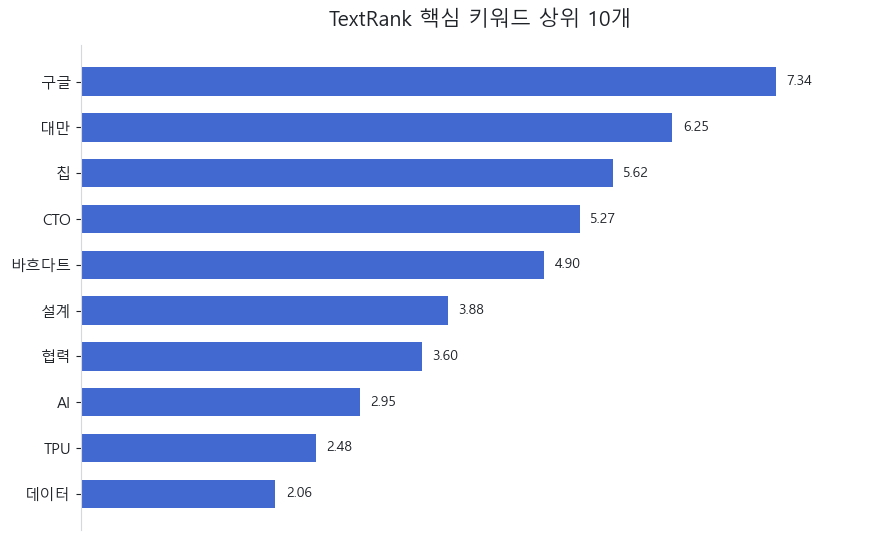

In [15]:
top10 = df_kw.head(10).iloc[::-1]          # barh 는 아래부터 그리므로 역순

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top10["키워드"], top10["TextRank"], color=BLUE, height=0.62)

# 값은 막대 끝에 직접 적는다 (눈금선을 따라가지 않아도 읽힌다)
for b, v in zip(bars, top10["TextRank"]):
    ax.text(v + max(top10["TextRank"]) * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:.2f}", va="center", fontsize=10, color=INK)

ax.set_title("TextRank 핵심 키워드 상위 10개", fontsize=15, pad=14, color=INK)
ax.set_xlabel("TextRank 점수", fontsize=11, color=MUTED)
ax.set_xlim(0, max(top10["TextRank"]) * 1.15)
ax.tick_params(colors=INK, labelsize=11)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#D5D8DD")
ax.xaxis.set_visible(False)                 # 직접 라벨이 있으므로 축은 지운다
plt.tight_layout()
plt.show()

## 2.3 보조 그래프 — 키워드 그래프(네트워크)

TextRank는 **그래프 알고리즘**이므로, 그래프 자체를 그려주면  
"왜 이 단어가 상위인가"(= 어떤 단어들과 연결되어 있는가)를 함께 보여줄 수 있다.

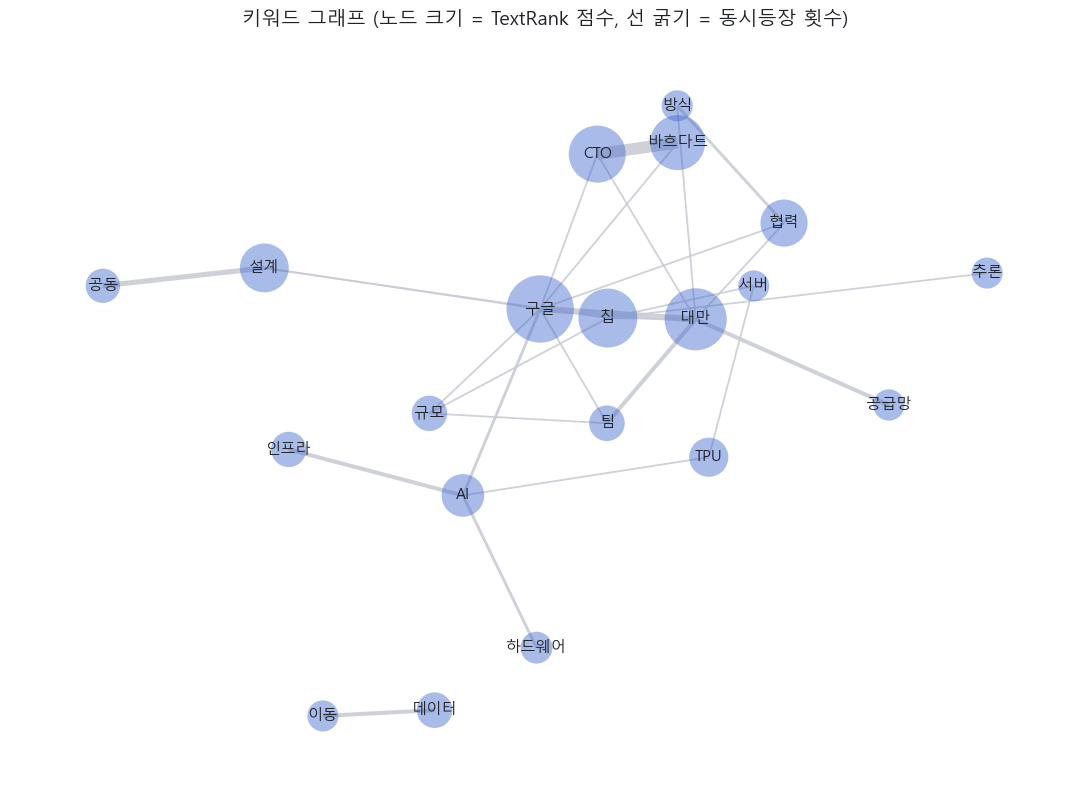

In [ ]:
TOP_N = 20
top_words = df_kw.head(TOP_N)["키워드"].tolist()
top_score = dict(zip(df_kw["키워드"], df_kw["TextRank"]))

Gs = nx.Graph()
Gs.add_nodes_from(top_words)
w2i = {w: i for i, w in enumerate(vocab)}
for a in range(TOP_N):
    for b in range(a + 1, TOP_N):
        wgt = W[w2i[top_words[a]]][w2i[top_words[b]]]
        if wgt > 0:
            Gs.add_edge(top_words[a], top_words[b], weight=wgt)

pos = nx.spring_layout(Gs, seed=42, k=0.9)
sizes = [top_score[n] * 320 for n in Gs.nodes()]
ew = [Gs[u][v]["weight"] for u, v in Gs.edges()]

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(Gs, pos, ax=ax, width=[0.5 + w * 0.8 for w in ew],
                       edge_color="#C9CDD4", alpha=0.9)
# 노드 투명도 alpha값을 낮춰야함.
nx.draw_networkx_nodes(Gs, pos, ax=ax, node_size=sizes,
                       node_color=BLUE, alpha=0.45, linewidths=0)
nx.draw_networkx_labels(Gs, pos, ax=ax, font_size=11,
                        font_family='Malgun Gothic', font_color=INK)
ax.set_title("키워드 그래프 (노드 크기 = TextRank 점수, 선 굵기 = 동시등장 횟수)",
             fontsize=14, pad=12, color=INK)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 중요도 그래프 시각화

### 주 그래프 : 가로 막대그래프

**선택 이유**

- **'크기 비교'를 위해서이다.**  
   키워드 중요도는 *이름표가 붙은 값들의 크기를 비교*하는 데이터다.  
   막대의 **길이**는 사람이 가장 정확하게 읽어내는 시각 요소(공통 기준선 위의 위치·길이)라서,  
   각도(원그래프)나 면적(버블)보다 오차가 훨씬 적다.

### 보조 그래프 ① : 네트워크 그래프

TextRank는 **그래프 위의 알고리즘**이다. 막대그래프는 결과(점수)만 보여줄 뿐  
*왜* 그 단어가 높은지는 설명하지 못한다. 네트워크 그래프는 노드 크기로 점수를,  
선 굵기로 동시등장 횟수를 함께 보여주므로 **알고리즘의 근거를 시각적으로 확인**할 수 있다.  
`구글`·`대만`이 중앙에서 여러 노드와 연결된 허브로 나타나는 것이 눈으로 보인다.

※ 다만 노드가 많아지면 선이 엉켜 읽을 수 없게 되므로 개수를 제한하는 식으로 조절한다.

---
# 3. Luhn Summarizer

Luhn(1958)의 아이디어는 아주 단순하다.

1. 문서에서 **너무 흔하지도, 너무 드물지도 않은 단어**를 '중요 단어'로 고른다.
   → 빈도 비율이 `a`(하한) 이상 `b`(상한) 이하인 단어
2. 각 문장에서 중요 단어가 **몰려 있는 구간(window)** 을 찾는다.
3. 문장 점수 = `(구간 내 중요 단어 수)² / 구간 길이`
   → 중요 단어가 **많이**, 그리고 **가깝게 뭉쳐** 있을수록 높은 점수
4. 점수 상위 N개 문장을 뽑아 원문 순서대로 배열한다

## 3.1 구현

In [19]:
def get_keywords_luhn(word_list, a=0.001, b=0.5):
    """
    a = min_ratio : 이보다 드물게 나오는 단어는 버린다 (일회성 단어 제거)
    b = max_ratio : 이보다 흔하게 나오는 단어는 버린다 (사실상 불용어 제거)
    """
    assert a < 1 and b < 1
    cnt = Counter(word_list)
    total = len(word_list)
    return {w for w, c in cnt.items() if a <= c / total <= b}

def get_sentence_weight(sentence, keywords):
    """문장 점수 = (구간 내 키워드 수)^2 / 구간 길이"""
    toks = get_nouns(sentence)

    ws, we = 0, -1
    for i, t in enumerate(toks):                 # 첫 키워드 위치
        if t in keywords:
            ws = i
            break
    for i in range(len(toks) - 1, -1, -1):       # 마지막 키워드 위치
        if toks[i] in keywords:
            we = i
            break

    if ws > we:                                   # 키워드가 하나도 없는 문장
        return 0.0

    window = we - ws + 1
    k = sum(1 for t in toks if t in keywords)
    return k * k / window

def luhn_summarize(text, n=3, a=0.001, b=0.5, verbose=True):
    words = get_nouns(text)
    keywords = get_keywords_luhn(words, a, b)
    sents = split_sentences_ko(text)

    weights = [(get_sentence_weight(s, keywords), i, s) for i, s in enumerate(sents)]
    top = sorted(weights, key=lambda x: -x[0])[:n]

    if verbose:
        print(f"전체 토큰 {len(words)}개 → 중요 단어 {len(keywords)}개 / 문장 {len(sents)}개")
    return sorted(top, key=lambda x: x[1])        # 원문 순서로 되돌려 반환

In [20]:
print(f"[원문] {KO_DOC_META['title']}\n")
summary_luhn = luhn_summarize(KO_DOC, n=3, a=0.001, b=0.5)
print("\n=== Luhn 요약 (a=0.001, b=0.5) ===")
for w, i, s in summary_luhn:
    print(f"[문장 {i:>2}] 점수 {w:6.2f}\n  {s}\n")

[원문] 구글 "대만과 어깨 나란히"…AI 인프라 협력, 발주에서 공동설계로

전체 토큰 333개 → 중요 단어 194개 / 문장 33개

=== Luhn 요약 (a=0.001, b=0.5) ===
[문장  2] 점수  18.00
  6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 '세미콘 타이완 2026' 마스터 포럼 및 글로벌 생태계 서밋에 참석해 강연한 뒤, 대만 언론 인터뷰에 처음으로 응했다.

[문장 12] 점수  17.00
  바흐다트 CTO는 "이건 이미 구매와 파트너의 문제가 아니다"라며 구글과 대만 업체들이 이미 깊은 수준의 공동 설계 단계에 들어섰고, 이런 협력이 매달 매 분기 매년 가속되고 있다고 설명했다.

[문장 17] 점수  17.00
  바흐다트 CTO는 구글의 설계와 제조 작업 상당수가 대만에서 이뤄지며, TSMC 생산라인에서 칩이 나오면 대만 팀이 가장 먼저 테스트를 수행하는 경우가 많다고 설명했다.



## 3.2 `a`, `b` 값을 바꿔가며 결과 비교

In [21]:
words_all = get_nouns(KO_DOC)
rows = []
for a, b in [(0.000, 0.99), (0.001, 0.50), (0.005, 0.50), (0.010, 0.50),
             (0.020, 0.50), (0.030, 0.50), (0.001, 0.02), (0.001, 0.01)]:
    ks = get_keywords_luhn(words_all, a, b)
    res = luhn_summarize(KO_DOC, n=2, a=a, b=b, verbose=False)
    rows.append({
        "a (min_ratio)": a,
        "b (max_ratio)": b,
        "중요 단어 수": len(ks),
        "선택 문장 번호": str([i for _, i, _ in res]),
        "1순위 문장": res[0][2][:40] + "..." if res else "",
    })
pd.DataFrame(rows)

,a (min_ratio),b (max_ratio),중요 단어 수,선택 문장 번호,1순위 문장
0,0.000,0.99,194,"[2, 12]",6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 ...
1,0.001,0.50,194,"[2, 12]",6일 대만 공상시보에 따르면 바흐다트 CTO는 지난 2일 대만에서 열린 ...
2,0.005,0.50,48,"[6, 16]",업계에서는 그가 행사 전 대만 공급망을 비공개로 방문해 TPU 서버 물량...
3,0.010,0.50,14,"[16, 17]",구글 대만 팀은 구글 AI 하드웨어 개발의 중요한 역할을 맡고 있다....
4,0.020,0.50,7,"[12, 17]","바흐다트 CTO는 ""이건 이미 구매와 파트너의 문제가 아니다""라며 구글과..."
5,0.030,0.50,5,"[1, 17]",아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수...
6,0.001,0.02,187,"[26, 29]",AI 에이전트가 동작할 때 대량의 데이터 이동과 작업 스케줄링이 필요해지...
7,0.001,0.01,180,"[26, 29]",AI 에이전트가 동작할 때 대량의 데이터 이동과 작업 스케줄링이 필요해지...


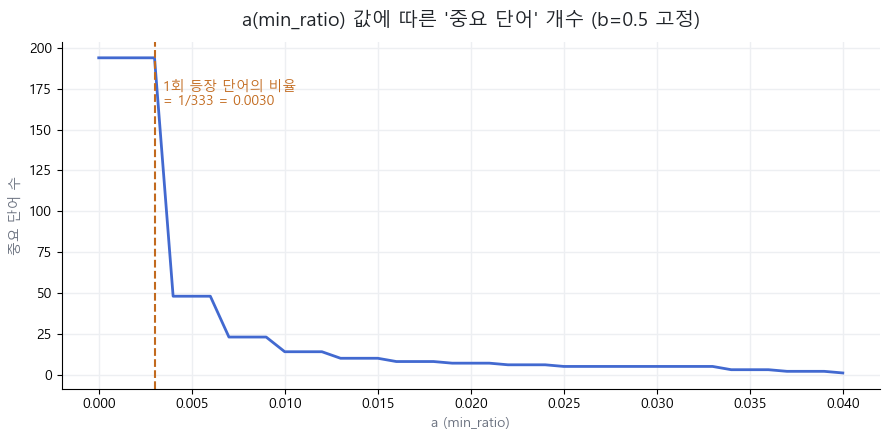

In [22]:
# a 값이 중요 단어 수를 어떻게 깎는지 곡선으로 확인
a_grid = np.linspace(0, 0.04, 41)
counts = [len(get_keywords_luhn(words_all, a, 0.5)) for a in a_grid]
one_time = 1 / len(words_all)          # 1회 등장 단어의 비율

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(a_grid, counts, color=BLUE, linewidth=2)
ax.axvline(one_time, color=ORANGE, linestyle="--", linewidth=1.5)
ax.text(one_time * 1.15, max(counts) * 0.85,
        f"1회 등장 단어의 비율\n= 1/{len(words_all)} = {one_time:.4f}",
        color=ORANGE, fontsize=10)
ax.set_title("a(min_ratio) 값에 따른 '중요 단어' 개수 (b=0.5 고정)", fontsize=14, pad=12, color=INK)
ax.set_xlabel("a (min_ratio)", color=MUTED)
ax.set_ylabel("중요 단어 수", color=MUTED)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(color="#EDEFF2", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
## 요약 결과에 대한 `a`, `b`의 의미

1. `a=0.001`은 짧은 문서에서 아무 역할도 못 한다.
  - 이 문서의 토큰은 333개다. 단어가 **딱 1번**만 나와도 비율이 `1/333 = 0.0030` 으로  
  이미 `a=0.001` 보다 크다. 즉 하한을 통과하지 못하는 단어가 존재할 수 없다.

2. `b`를 잘못 낮추면 요약이 망가진다.
  - `b=0.02` 로 두면 비율이 0.02를 넘는 단어(`구글` 16회 → 0.048, `대만` 13회 → 0.039)가  
  **중요 단어에서 제외된다.** 그 결과 기사의 주제와 무관한, 잡다한 단어가 몰려 있는 문장이 1순위로 뽑힐 수 있다.

---
# 4. TextRank 문서 요약

키워드 추출과 **알고리즘은 완전히 같다.** 그래프의 정의만 바꾼다.

| | 키워드 추출 | 문서 요약 |
|---|---|---|
| 노드 | 단어 | **문장** |
| 엣지 | window 안 동시등장 | **문장 간 유사도** |
| 결과 | 상위 단어 | 상위 **문장** |

## 4.1 구현

In [ ]:
def jaccard(t1, t2):
    """자카드 유사도 = 교집합 / 합집합"""
    s1, s2 = set(t1), set(t2)
    union = s1 | s2
    return len(s1 & s2) / len(union) if union else 0.0

def mihalcea(t1, t2):
    """TextRank 원 논문의 문장 유사도 : 공통 단어 수 / (log|S1| + log|S2|)"""
    s1, s2 = set(t1), set(t2)
    common = len(s1 & s2)
    if common == 0 or len(s1) < 2 or len(s2) < 2:
        return 0.0
    return common / (np.log(len(s1)) + np.log(len(s2)))

def build_sentence_graph(sent_tokens, sim=jaccard):
    n = len(sent_tokens)
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            s = sim(sent_tokens[i], sent_tokens[j])
            W[i][j] = s
            W[j][i] = s
    return W

def textrank_summarize(text, n=3, sim=jaccard,
                       tokenizer=None, splitter=None, verbose=True):
    tokenizer = tokenizer or get_nouns
    splitter = splitter or split_sentences_ko

    sents = splitter(text)
    sent_tokens = [tokenizer(s) for s in sents]
    W = build_sentence_graph(sent_tokens, sim)
    score, iters = textrank_score(W)

    if verbose:
        print(f"문장 {len(sents)}개 / 엣지 {int((W > 0).sum() / 2)}개 / {iters}회 반복 후 수렴")

    idx = np.argsort(-score)[:n]
    return sorted([(score[i], int(i), sents[i]) for i in idx], key=lambda x: x[1]), score, sents

summary_tr, sent_score, sents_ko = textrank_summarize(KO_DOC, n=3)
print("\n=== TextRank 요약 (자카드 유사도) ===")
for w, i, s in summary_tr:
    print(f"[문장 {i:>2}] 점수 {w:6.3f}\n  {s}\n")

문장 33개 / 엣지 253개 / 32회 반복 후 수렴

=== TextRank 요약 (자카드 유사도) ===
[문장  0] 점수  1.463
  구글이 대만 공급망과의 관계를 단순 발주와 납품을 넘어 칩 설계 단계부터 함께 만드는 '공동 설계' 체제로 바꾸고 있다.

[문장 12] 점수  1.559
  바흐다트 CTO는 "이건 이미 구매와 파트너의 문제가 아니다"라며 구글과 대만 업체들이 이미 깊은 수준의 공동 설계 단계에 들어섰고, 이런 협력이 매달 매 분기 매년 가속되고 있다고 설명했다.

[문장 17] 점수  1.666
  바흐다트 CTO는 구글의 설계와 제조 작업 상당수가 대만에서 이뤄지며, TSMC 생산라인에서 칩이 나오면 대만 팀이 가장 먼저 테스트를 수행하는 경우가 많다고 설명했다.



In [25]:
# 유사도 함수를 바꾸면 결과가 어떻게 달라지는가
summary_mh, _, _ = textrank_summarize(KO_DOC, n=3, sim=mihalcea, verbose=False)
print("자카드 유사도  선택 문장 :", [i for _, i, _ in summary_tr])
print("Mihalcea 유사도 선택 문장 :", [i for _, i, _ in summary_mh])
print()
for w, i, s in summary_mh:
    print(f"[문장 {i:>2}] {w:6.3f}  {s[:60]}...")

자카드 유사도  선택 문장 : [0, 12, 17]
Mihalcea 유사도 선택 문장 : [1, 12, 17]

[문장  1]  1.543  아민 바흐다트 구글 최고기술책임자(CTO) 겸 인공지능(AI) 인프라 수석부사장은 양측의 협력 방식을 "어깨...
[문장 12]  1.805  바흐다트 CTO는 "이건 이미 구매와 파트너의 문제가 아니다"라며 구글과 대만 업체들이 이미 깊은 수준의 공...
[문장 17]  1.917  바흐다트 CTO는 구글의 설계와 제조 작업 상당수가 대만에서 이뤄지며, TSMC 생산라인에서 칩이 나오면 대...


---
## 4.2 영어 뉴스에 그대로 적용하기

**바꿔야 하는 것은 토크나이저뿐이다.**  
`build_word_graph`, `textrank_score`, `build_sentence_graph`, `textrank_summarize` 는  
그대로 사용한다.

In [32]:
import nltk
EN_STOP = set(nltk.corpus.stopwords.words())

def en_sentences(text):
    tmp = re.sub(r"(\d)\.(\d)", r"\1<DOT>\2", text)          # $12.93 보호
    for ab in ["Mr", "Mrs", "Ms", "Dr", "Inc", "Ltd", "Co", "U.S", "e.g", "i.e", "No", "St", "vs"]:
        tmp = tmp.replace(ab + ".", ab + "<DOT>")
    parts = re.split(r'(?<=[.!?])\s+(?=["\'(A-Z0-9])', tmp)
    return [p.replace("<DOT>", ".").strip() for p in parts if p.strip()]

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

def en_tokens(text):
    from nltk import word_tokenize, pos_tag
    return [w.lower() for w, p in pos_tag(word_tokenize(text))
            if p.startswith(("NN", "JJ")) and w.lower() not in EN_STOP and len(w) > 2]

en_tok = en_tokens(EN_DOC)
en_sents = en_sentences(EN_DOC)
print(f"토큰 {len(en_tok)}개 / 고유 {len(set(en_tok))}개 / 문장 {len(en_sents)}개")
print(en_tok[:15])

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jason\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jason\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


토큰 169개 / 고유 98개 / 문장 27개
['weeks', 'rumors', 'nvidia', 'today', 'hugging', 'platform', 'models', 'applications', 'developers', 'datasets', 'blog', 'post', 'nvidia', 'ceo', 'jensen']


In [35]:
print(f"[Source] {EN_DOC_META['title']}\n")
summary_en, _, _ = textrank_summarize(EN_DOC, n=3,
                                      tokenizer=en_tokens, splitter=en_sentences)
print("\n=== TextRank summary (English) ===")
for w, i, s in summary_en:
    print(f"[{i:>2}] {w:6.3f}  {s}\n")

[Source] Nvidia confirms it will buy Hugging Face for $12.9 billion

문장 27개 / 엣지 162개 / 17회 반복 후 수렴

=== TextRank summary (English) ===
[ 6]  1.928  Huang touted Nvidia's contributions and said that the chip company has released more than 500 models and 250 open datasets on Hugging Face.

[24]  1.825  Huang pitched open models while answering one of the analysts and said that almost all open models run on Nvidia hardware.

[26]  1.797  In July, Delangue said that Nvidia's open model helped Hugging Face defend against cyberattacks after proprietary models failed to protect the platform.



## 4.2 비슷한 뉴스 10개를 하나로 합쳐서 수행

In [39]:
merged = "\n".join(d["text"] for d in SIMILAR_DOCS)
merged_tokens = get_nouns(merged)
merged_sents = split_sentences_ko(merged)

print(f"합친 문서 : {len(merged):,}자 / 토큰 {len(merged_tokens):,}개 "
      f"/ 고유 {len(set(merged_tokens)):,}개 / 문장 {len(merged_sents)}개")

합친 문서 : 6,243자 / 토큰 1,009개 / 고유 418개 / 문장 112개


In [38]:
print("=== 합본 10개 문서의 TextRank 요약 3문장 ===")
summary_m, _, _ = textrank_summarize(merged, n=3)
for w, i, s in summary_m:
    print(f"[문장 {i:>3}] {w:6.3f}\n  {s}\n")

=== 합본 10개 문서의 TextRank 요약 3문장 ===
문장 112개 / 엣지 1403개 / 35회 반복 후 수렴
[문장  63]  2.074
  삼성전자가 고대역폭메모리(HBM) 시장에서 업계 1위 SK하이닉스와 격차를 좁혔다.

[문장  68]  2.109
  반면 삼성전자는 올 2분기 33% 점유율로 SK하이닉스와 격차를 17%포인트로 좁혔다.

[문장  76]  1.817
  반면 시장점유율 1위인 삼성전자의 낸드 투자는 증설보다 세대 전환에 초점이 맞춰져 있어 총 생산능력이 오히려 감소하는 추세다.



## 4.3 만약, 100개·1000개 문서라면?

TextRank 요약의 병목은 **문장 유사도 행렬**이다.  
문장이 n개면 계산해야 할 쌍이 `n(n-1)/2` 개 → **O(n²)**.  
실제로 시간을 재서 확인하고, 100개·1000개 문서를 추정해 본다.

In [40]:
base_tokens = [get_nouns(s) for s in merged_sents]

rows = []
for mult in [1, 2, 4, 8]:
    st = base_tokens * mult                       # 문장 수를 배로 늘려가며 측정
    t0 = time.time()
    _ = build_sentence_graph(st)
    elapsed = time.time() - t0
    n = len(st)
    rows.append({"문장 수": n,
                 "계산할 쌍": n * (n - 1) // 2,
                 "소요 시간(초)": round(elapsed, 3),
                 "행렬 메모리(MB)": round(n * n * 8 / 1e6, 1)})
df_time = pd.DataFrame(rows)
df_time["직전 대비 시간 배율"] = (df_time["소요 시간(초)"] / df_time["소요 시간(초)"].shift(1)).round(2)
df_time

,문장 수,계산할 쌍,소요 시간(초),행렬 메모리(MB),직전 대비 시간 배율
0,112,6216,0.010,0.1,NaN
1,224,24976,0.036,0.4,3.60
2,448,100128,0.143,1.6,3.97
3,896,400960,0.553,6.4,3.87


In [41]:
# 측정값으로 O(n^2) 상수를 구해 100개 / 1000개 문서를 추정
n_last = df_time.iloc[-1]["문장 수"]
t_last = df_time.iloc[-1]["소요 시간(초)"]
sent_per_doc = len(merged_sents) / len(SIMILAR_DOCS)

rows = []
for n_docs in [1, 10, 100, 1000, 10000]:
    n = int(sent_per_doc * n_docs)
    rows.append({
        "문서 수": n_docs,
        "예상 문장 수": f"{n:,}",
        "계산할 쌍": f"{n * (n - 1) // 2:,}",
        "예상 소요 시간": f"{t_last * (n / n_last) ** 2:,.1f} 초",
        "유사도 행렬 메모리": f"{n * n * 8 / 1e9:.3f} GB",
    })
pd.DataFrame(rows)

,문서 수,예상 문장 수,계산할 쌍,예상 소요 시간,유사도 행렬 메모리
0,1,11,55,0.0 초,0.000 GB
1,10,112,"6,216",0.0 초,0.000 GB
2,100,"1,120","626,640",0.9 초,0.010 GB
3,1000,"11,200","62,714,400",86.4 초,1.004 GB
4,10000,"112,000","6,271,944,000","8,640.6 초",100.352 GB


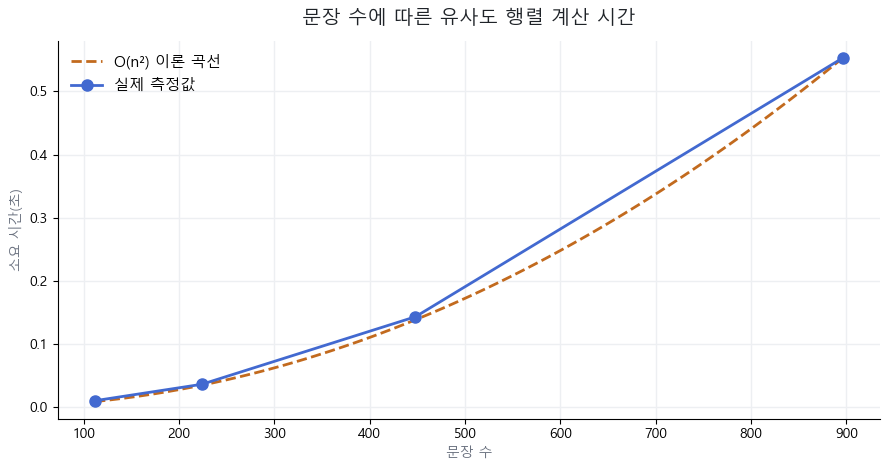

In [42]:
# 측정값과 O(n^2) 이론 곡선 비교
n_vals = df_time["문장 수"].values
t_vals = df_time["소요 시간(초)"].values
c = t_vals[-1] / n_vals[-1] ** 2                 # 마지막 점으로 상수 추정
n_fit = np.linspace(n_vals.min(), n_vals.max(), 100)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(n_fit, c * n_fit ** 2, color=ORANGE, linewidth=2, linestyle="--", label="O(n²) 이론 곡선")
ax.plot(n_vals, t_vals, "o-", color=BLUE, linewidth=2, markersize=8, label="실제 측정값")
ax.set_title("문장 수에 따른 유사도 행렬 계산 시간", fontsize=14, pad=12, color=INK)
ax.set_xlabel("문장 수", color=MUTED)
ax.set_ylabel("소요 시간(초)", color=MUTED)
ax.legend(frameon=False, fontsize=11)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(color="#EDEFF2", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
## TextRank 를 문서 요약에 적용할 때의 장점

### 1. 언어 독립성 — 영어 뉴스에서 확인한 것

4.1에서 영어 기사를 처리할 때 **바꾼 것은 두 개의 함수뿐**이었다.

```
get_nouns          → en_tokens      (형태소 분석기 → 영어 토큰화)
split_sentences_ko → en_sentences   (한국어 종결 규칙 → 영어 종결 규칙)
```

`build_word_graph`, `textrank_score`, `build_sentence_graph`, `textrank_summarize` 는  
**그대로 사용 가능했다.**

- **학습 데이터·정답 라벨이 필요 없다(비지도).**  
  지도학습 요약 모델은 언어마다 (문서, 요약) 쌍 코퍼스를 새로 구해야 하지만,  
  TextRank는 **문서 한 건만 있으면 바로 돌아간다.**
- **언어 자원 의존이 최소한이다.** 필요한 것은 "문장을 나누는 법"과 "단어를 나누는 법"뿐이고,  
  알고리즘 본체는 **그래프 위의 수치 계산일 뿐 언어를 몰라도 상관없다.**
- **도메인도 가리지 않는다.** TextRank는 문서 안의 통계만 쓰므로 도메인이 바뀌어도 그대로 쓸 수 있다.

### 2. 확장성 — 여러 문서를 합쳤을 때

**(1) 다중 문서 요약이 자연스럽게 된다.**

TextRank는 "문장 집합"만 있으면 되고, **그 문장들이 몇 개의 문서에서 왔는지는 신경 쓰지 않는다.**  
그래서 10개 문서를 이어붙이는 것만으로 다중 문서 요약기가 된다.

그리고 결과는 단순한 합집합이 아니게 되는데,

- 개별 문서 단독으로 돌리면 `DDI/UMC`(S01), `키오시아/지분`(S03) 처럼
  **그 기사에만 있는 단어**가 상위에 온다.
- 10개를 합치면 `삼성전자`, `HBM`, `SK하이닉스`, `점유`, `분기` 처럼
  **여러 기사에 걸쳐 반복되는 공통 주제어**가 상위로 올라온다.

이유는 그래프 구조에 있다. 여러 문서에 등장하는 단어는 **문서마다 새로운 이웃**을 얻어   
연결이 늘어나고, 한 문서에만 있는 단어는 이웃이 그대로다.  
**문서를 더 넣을수록 공통 주제가 저절로 강화되는 구조**다.  
요약 문장도 마찬가지로, 다른 기사의 문장들과도 유사한 문장(= 여러 기사가 공통으로 다루는 내용)이 뽑힌다.

**(2) 그러나 O(n²) 라는 벽이 있다.**

4.3의 측정 결과, 문장 수를 2배로 늘릴 때마다 시간이 약 **4배**가 되었다.
전형적인 이차 함수 형태이다.

| 문서 수 | 문장 수 | 계산할 문장 쌍 | 유사도 행렬 메모리 |
|---|---|---|---|
| 10개 | 약 110 | 약 6천 | 0.1 MB 미만 |
| 100개 | 약 1,100 | 약 63만 | 약 0.01 GB |
| 1,000개 | 약 11,000 | 약 6,300만 | 약 1 GB |
| 10,000개 | 약 110,000 | 약 63억 | 약 100 GB |

- **100개**는 문제없다. 노트북에서 수 초 안에 끝난다.
- **1,000개**부터 부담스러워진다. 문장 쌍이 6천만 개를 넘고 밀집 행렬만 1GB다.
  파이썬 이중 루프로는 몇 분이 걸린다.
- **10,000개**는 현실적으로 불가능하다. 행렬만 100GB다.

**실무에서의 해결 방법**

1. **희소 행렬 + 벡터 연산** — 자카드 대신 TF-IDF 코사인을 쓰면  
   `sklearn` 의 희소 행렬 곱 한 번(`X @ X.T`)으로 유사도를 계산할 수 있다.  
   파이썬 루프가 사라져 수십~수백 배 빨라진다.
2. **엣지 가지치기(threshold)** — 유사도가 임계값 이하인 쌍은 아예 저장하지 않는다.  
   문서가 많을수록 대부분의 문장 쌍은 유사도가 0에 가까우므로 그래프가 훨씬 가벼워진다.  
3. **근사 최근접 이웃(ANN)** — 각 문장마다 상위 k개 이웃만 찾아 연결한다(k-NN 그래프).  
   그러면 엣지가 `O(kn)` 으로 줄어 선형에 가까워진다.
4. **2단계 요약(hierarchical)** — 문서별로 먼저 요약한 뒤, 그 요약문들을 다시 요약한다.  
   1,000개 문서라면 문서당 3문장씩 → 3,000문장 → 다시 요약. 실무에서 가장 흔한 방식이다.
5. **클러스터링 후 요약** — 먼저 주제별로 문서를 묶고, 클러스터 안에서만 요약한다.  
   "비슷한 뉴스"를 모아야 요약이 의미 있으므로 어차피 필요한 단계이기도 하다.